# Module: Region Similarity

Assuming that transcripts are homogeneously distributed throughout the cell, we expect there to be similar expression of genes in the nucleus and in the rest of the cell. If this is not the case, it can be indicative of transcript spillover from adjacent cells.

<center>
 <img src='../_static/img/docs/region_similarity.png' width='90%' />
</center>

The `region similarity` (`rs`) module provides metrics to assess how similar the expression profiles are between subcellular regions (e.g., cell and nucleus). 

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
from scipy.stats import linregress

import segtraq

We start out by loading the data into a `SegTraQ` object.

In [ ]:
sdata = sd.read_zarr(
    "/g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr/"
)
st = segtraq.SegTraQ(
    sdata,
    tables_centroid_x_key=None,
    tables_centroid_y_key=None,
    points_background_id=-1,  # "UNASSIGNED" for Xenium prime
)

sdata

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No centroids specified for tables. Centroids will be automatically computed from shapes.
  validate_spatialdata(


SpatialData object, with associated Zarr store: /g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_xenium_crop.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 2500, 2500), (1, 1250, 1250), (1, 625, 625), (1, 313, 313), (1, 156, 156)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1563, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1501, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1563, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

As you can see, the `spatialdata`dataset contains cell and nuclear masks as `shapes`. It is important that you have a nuclear segmentation in your object, otherwise you will not be able to compute the metrics below.

## Intersection over Union between cell and nucleus masks

First, we get the nucleus that overlaps most with each cell and compute the Intersection over Union (IoU) between cell and nuclear masks using the method `match_nuclei_to_cells()`.

In [6]:
results_df = st.rs.match_nuclei_to_cells()
results_df.head()

,cell_id,nucleus_id,iou,nucleus_fraction
0,6327,6327.0,0.051420,1.0
1,6328,6328.0,0.064608,1.0
2,6330,6330.0,0.047572,1.0
3,6331,6331.0,0.042835,1.0
4,6332,6332.0,0.041484,1.0


For each `cell_id`, we obtain the ID (`nucleus_id`) of the nucleus mask with the highest `IoU`. If a cell does not overlap with any nucleus, the function returns a missing value for `nucleus_id`. In addition to the `IoU`, we also report the fraction of the nucleus that overlaps with the cell. If the nucleus has an invalid geometry, `IoU` and `nucleus_fraction` are reported as `NA`.

Let's see what this looks like when we plot the IoU spatially.

WARNING  Found 64 NaN values in color data. These observations will be colored with the 'na_color'.                


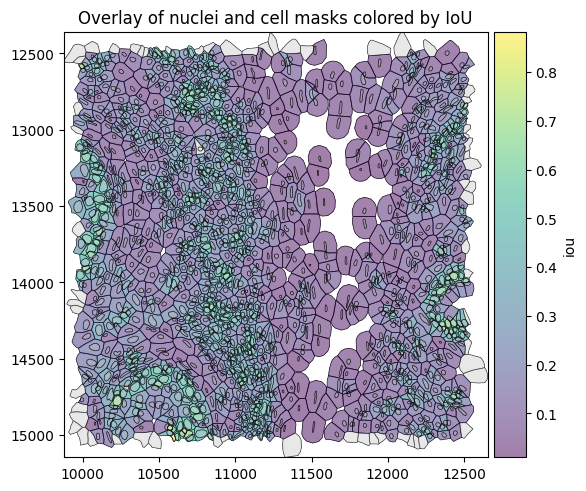

In [7]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
sdata.pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

We will quickly set up some helper functions to facilitate plotting.

In [8]:
# helper functions for plotting
def plot_histogram(
    df,
    column,
    bins=30,
    figsize=(6, 5),
    color="steelblue",
    edgecolor="black",
    show_median=True,
    median_kwargs=None,
    median_color="red",
    title=None,
    xlabel=None,
    ylabel="Count",
    ax=None,
):
    values = df[column].dropna()
    median_value = np.median(values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    ax.hist(values, bins=bins, color=color, edgecolor=edgecolor)

    if show_median:
        median_kwargs = median_kwargs or {}
        ax.axvline(
            median_value,
            linestyle="--",
            linewidth=2,
            color=median_color,
            label=f"Median = {median_value:.2f}",
            **median_kwargs,
        )
        ax.legend()

    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel(ylabel)

    plt.show()


def plot_regression(
    df,
    x,
    y,
    figsize=(6, 6),
    dropna=True,
    ci=95,
    scatter_kws=None,
    line_kws=None,
    title=None,
    xlabel=None,
    ylabel=None,
    r2_loc=(0.05, 0.95),
    r2_fmt="{:.3f}",
    ax=None,
):
    data = df[[x, y]]
    if dropna:
        data = data.dropna()

    # Regression stats
    slope, intercept, r_value, p_value, std_err = linregress(data[x], data[y])
    r_squared = r_value**2

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    scatter_kws = scatter_kws or {"alpha": 0.6}
    line_kws = line_kws or {"color": "red"}

    sns.regplot(
        data=data,
        x=x,
        y=y,
        ci=ci,
        scatter_kws=scatter_kws,
        line_kws=line_kws,
        ax=ax,
    )

    # R² annotation
    ax.text(
        r2_loc[0],
        r2_loc[1],
        rf"$R^2 = {r2_fmt.format(r_squared)}$",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.set_title(title or f"{y} vs. {x}")
    ax.grid(True)

    plt.show()

We can now investigate what the distribution of IoUs looks like.

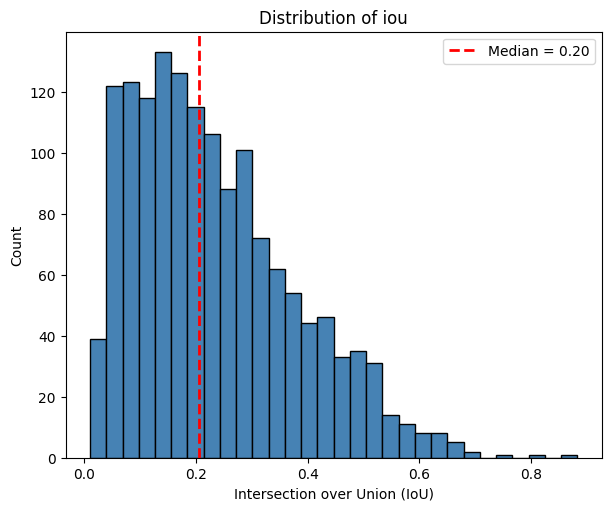

In [9]:
plot_histogram(
    df=sdata["table"].obs,
    column="iou",
    xlabel="Intersection over Union (IoU)",
)

## Expression similarity between cell and nucleus

Now that we have matched each cell with a nucleus, we can investigate how similar the expression profiles are between the nucleus and the whole cell (including the nucleus). For this, we use the function `similarity_nucleus_cell()`.

In [10]:
similarity_df = st.rs.similarity_nucleus_cell()

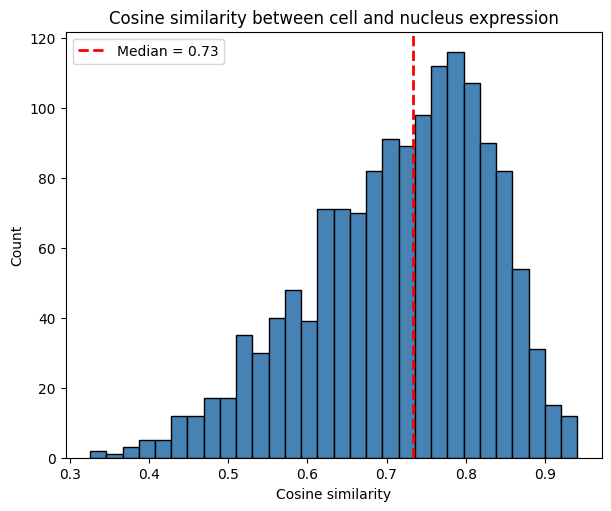

In [11]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_nucleus_cell",
    title="Cosine similarity between cell and nucleus expression",
    xlabel="Cosine similarity",
)

The histogram shows the distribution of cosine similarity values across cells. It is right-skewed, with a median of 0.73. This provides intuition about possible spatial spillover: cells may be contaminated by neighboring cells, assuming that nuclei capture expression with less contamination due to their smaller radius.

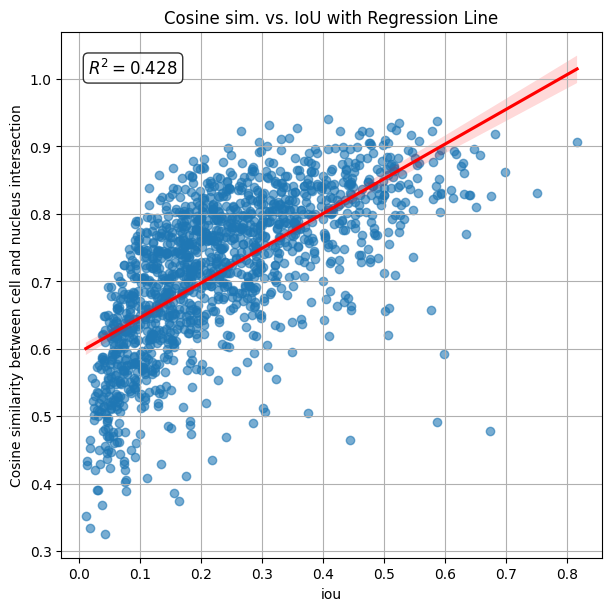

In [12]:
plot_regression(
    df=sdata["table"].obs,
    x="iou",
    y="similarity_nucleus_cell",
    title="Cosine sim. vs. IoU with Regression Line",
    ylabel="Cosine similarity between cell and nucleus intersection",
)

The calculated R2 (coefficient of determination) is 0.428, indicating that similarity between cell and nucleus increases with their IoU. 

The spatial plot below shows cell boundaries colored by cosine similarity between the nucleus and the cell. Cells whose transcripts are distributed across the nucleus region tend to have higher similarity with the nucleus, while cells whose transcripts are located outside the nuclear region —potentially due to spillover from neighboring cells— tend to exhibit lower similarity.

WARNING  Found 64 NaN values in color data. These observations will be colored with the 'na_color'.                
WARNING  Found 106 NaN values in color data. These observations will be colored with the 'na_color'.               


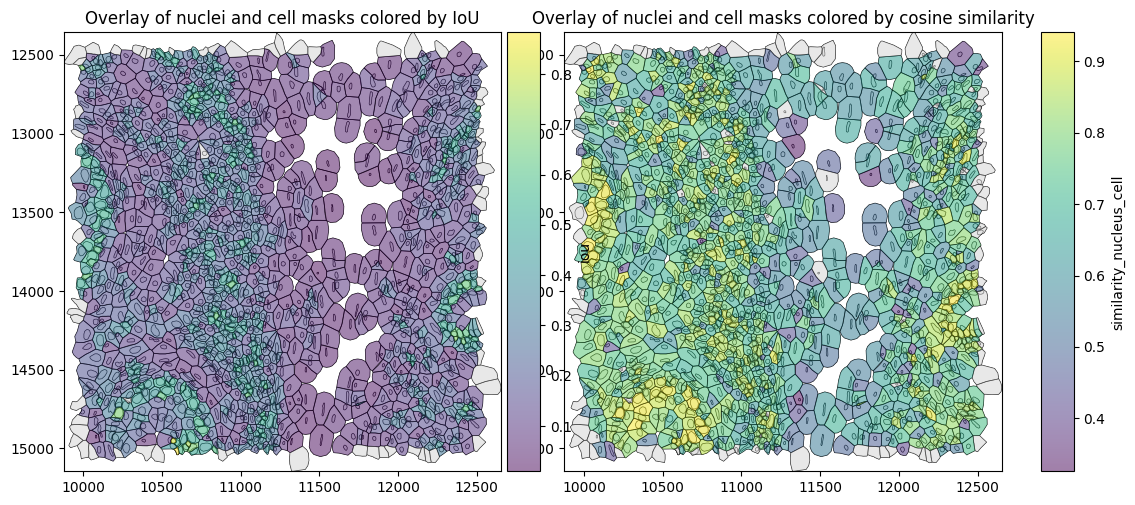

In [17]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=ax[0], title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=ax[1], title="Overlay of nuclei and cell masks colored by cosine similarity", colorbar=True)

Let's have a look at some cells with a low IoU, but a high similarity between the nucleus and the whole cell.

In [18]:
obs = sdata["table"].obs
df = obs[["cell_id", "iou", "similarity_nucleus_cell"]].dropna()
df.loc[df["iou"] < 0.1].sort_values("similarity_nucleus_cell", ascending=False).head()

,cell_id,iou,similarity_nucleus_cell
78681,78682,0.093248,0.789921
77479,77480,0.096786,0.789197
77214,77215,0.091966,0.785432
94651,94652,0.099583,0.772633
77471,77472,0.096177,0.767846


We can see that there are some cells with high `similarity_nucleus_cell` despite low `IoU`. Let's investigate one of these cells in more detail. By plotting the cell (centroid marked by grey cross) with its nucleus (centroid marked by black cross) and assigned transcripts (red), we can see that for this cell, the nucleus is small in comparison to the cell, however the transcripts are still somewhat homogeneously distributed within the cell, leading to the high similarity.

In [20]:
cid = (
    df.loc[df["iou"] < 0.1]
    .dropna(subset=["similarity_nucleus_cell"])
    .sort_values("similarity_nucleus_cell", ascending=False)
    .iloc[0]["cell_id"]
)
cid

np.float64(78682.0)

In [60]:
# helper function for plotting
def plot_cell_with_nucleus_and_transcripts(
    cid: float | int,
    title: str,
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding=200,
    points_gene_key="feature_name",
    tables_cell_id_key="cell_id",
    points_cell_id_key="cell_id",
    genes=None,
    center_layer="nucleus_boundaries",
    outer_layer="cell_boundaries",
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs.index == cid

    # compute x,y of cell and nucleus centroids in µm space
    centroid_x_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.x
    centroid_y_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.y
    centroid_x_cell = centroid_x_cell_px / pix_to_um_scale_factor
    centroid_y_cell = centroid_y_cell_px / pix_to_um_scale_factor

    nid = sdata["table"].obs.loc[sdata["table"].obs[tables_cell_id_key] == cid, "nucleus_id"]
    centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans[points_cell_id_key] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

    # zoom in for better visibility
    sdata_cropped = sdata.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[centroid_x_cell - padding, centroid_y_cell - padding],
        max_coordinate=[centroid_x_cell + padding, centroid_y_cell + padding],
        target_coordinate_system="global",
    )

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(6, 6), constrained_layout=True)[1]

    plot = sdata_cropped.pl.render_shapes(
        element=center_layer,
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element=outer_layer,
        color="focal_cell",
        fill_alpha=0.1,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    )

    if genes is None:
        plot = plot.pl.render_points(
            "transcripts_2",
            color="focal_cell",
            fill_alpha=0.1,
            groups=["focal_cell"],
            palette=["red"],
        )
    else:
        plot = plot.pl.render_points(
            "transcripts",
            color=points_gene_key,
            fill_alpha=0.1,
            groups=genes,
            palette=["red"],
        )

    plot.pl.show(
        ax=axes,
        title=title,
        colorbar=True,
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

WARNING  No table name provided, using 'table' as fallback for color mapping.                                      


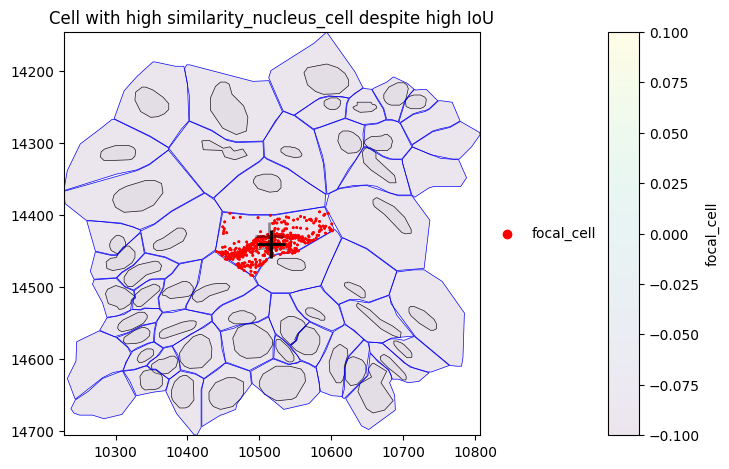

In [28]:
plot_cell_with_nucleus_and_transcripts(cid, title="Cell with high similarity_nucleus_cell despite high IoU")

Just looking at the similarity between the nucleus and the entire cell isn't specific enough. As a better metric, we therefore compute the similarity between the transcripts in the cell region intersecting the nucleus and the transcripts in the remaining cell region (we call this the cytoplasm, however with Proseg, this can also include transcripts that were originally measured outside of the cell). 

## Similarity between Nucleus and Cytoplasm

The function `similarity_nucleus_cytoplasm()` computes the cosine similarity between the spatial transcript feature counts within the nucleus and the cytoplasm. It is applicable only when nuclear masks are available. It returns `NaN` when the regions have no or not a sufficient number of overlapping transcripts (`min_transcripts`, `min_genes`). A low correlation/similarity may indicate that the cell boundary extension captures neighborhood or ambient signal rather than true intracellular expression—a concern similarly highlighted by segmentation benchmarks such as [Baysor](https://www.nature.com/articles/s41587-021-01044-w). This is based on the assumption that transcripts are homogeneously distributed within the cell and not localized in specific subcellular regions. 

In [29]:
sim_nuc_cyto_df = st.rs.similarity_nucleus_cytoplasm()
sim_nuc_cyto_df.head()

,cell_id,nucleus_id,iou,nucleus_fraction,similarity_nucleus_cytoplasm
0,6327,6327.0,0.051420,1.0,0.447169
1,6328,6328.0,0.064608,1.0,0.412166
2,6330,6330.0,0.047572,1.0,0.447582
3,6331,6331.0,0.042835,1.0,0.452131
4,6332,6332.0,0.041484,1.0,0.468873


The histogram below shows that the cosine similarity between the nucleus and remaining part of the cell is 0.45. 

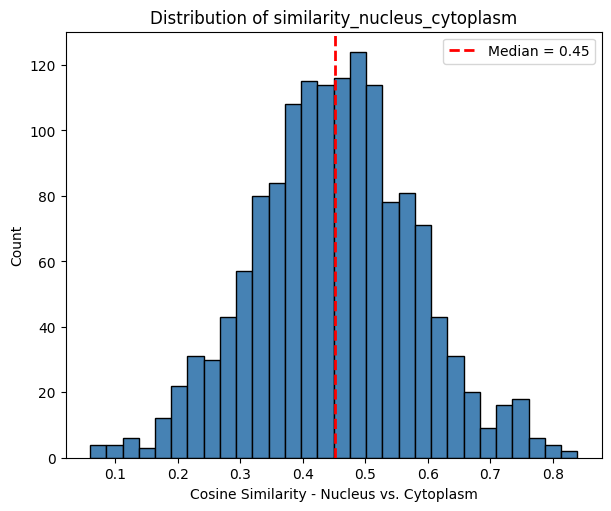

In [30]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_nucleus_cytoplasm",
    xlabel="Cosine Similarity - Nucleus vs. Cytoplasm",
)

The scatter plot below visualizes the cosine similarity between transcript counts in the intersection and remainder of each cell, plotted against the Intersection over Union (IoU) with the nucleus. The calculated R2 value is 0.032, indicating that `similarity_nucleus_cytoplasm` less dependent on `IoU` than `similarity_cell_nucleus`.

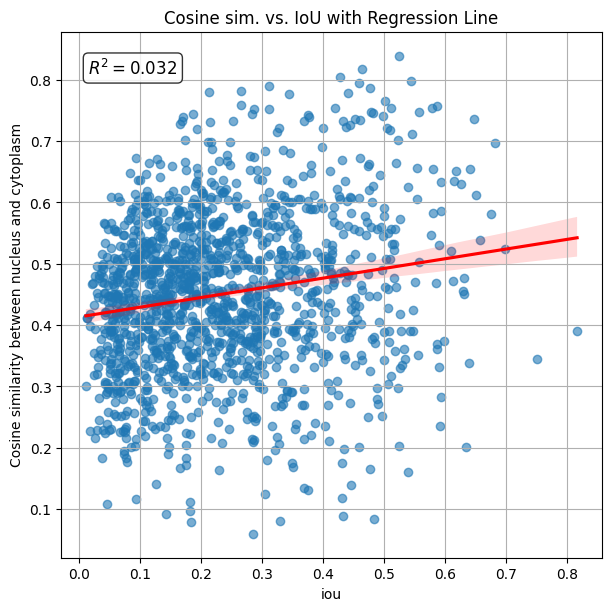

In [31]:
plot_regression(
    df=sdata["table"].obs,
    x="iou",
    y="similarity_nucleus_cytoplasm",
    title="Cosine sim. vs. IoU with Regression Line",
    ylabel="Cosine similarity between nucleus and cytoplasm",
)

The spatial plots below shows the spatial distribution of computed correlations. The cosine similarity between parts can be a measure of how much neighboring signal is captured. 

WARNING  Found 64 NaN values in color data. These observations will be colored with the 'na_color'.                
WARNING  Found 106 NaN values in color data. These observations will be colored with the 'na_color'.               
WARNING  Found 117 NaN values in color data. These observations will be colored with the 'na_color'.               


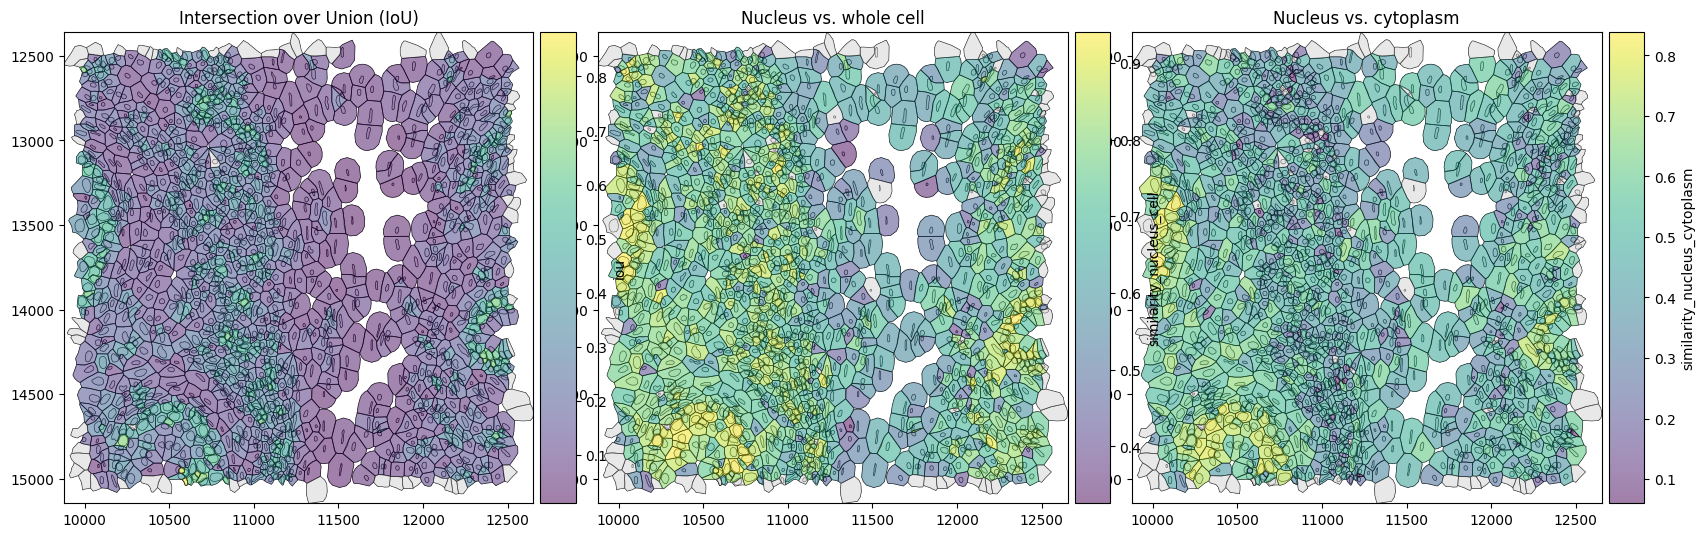

In [32]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Intersection over Union (IoU)",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[1],
    title="Nucleus vs. whole cell",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cytoplasm",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[2],
    title="Nucleus vs. cytoplasm",
    colorbar=True,
    figsize=(6, 6),
)

Above, we can see that there are some cells with low cosine similarity between parts despite high `IoU`. 

## Similarity between the cell center and border

The function `similarity_center_border()` computes the cosine similarity between gene expression in the cell interior (“center”) and outer ring (“border”).

Specifically, it:

1. Computes an equivalent radius for each cell and defines two erosion distances.
2. Constructs:
- Border: outer ring of the cell
- Center: inner eroded region
- A buffer region between them is ignored
3. Assigns transcripts to center and border regions.
4. Computes expression profiles and applies normalization and log transformation.
5. Computes cosine similarity between center and border expression.

In [44]:
center_border_df = st.rs.similarity_center_border()

In [45]:
center_border_df.head()

,cell_id,similarity_center_border
0,6327,0.523234
1,6328,0.413511
2,6330,0.393222
3,6331,0.460458
4,6332,0.455156


The histogram below shows the distribution of the similarity between the cell center and border.

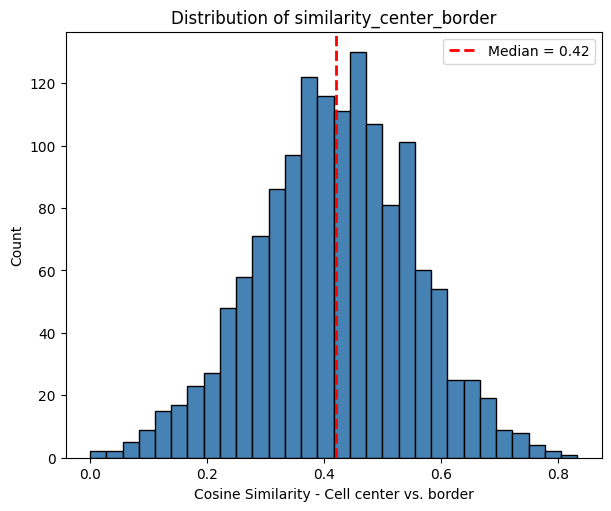

In [46]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_center_border",
    xlabel="Cosine Similarity - Cell center vs. border",
)

The spatial plots below shows the spatial distribution of computed similarity. 

INFO     Converted 1562 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                            
WARNING  Found 128 NaN values in color data. These observations will be colored with the 'na_color'.               


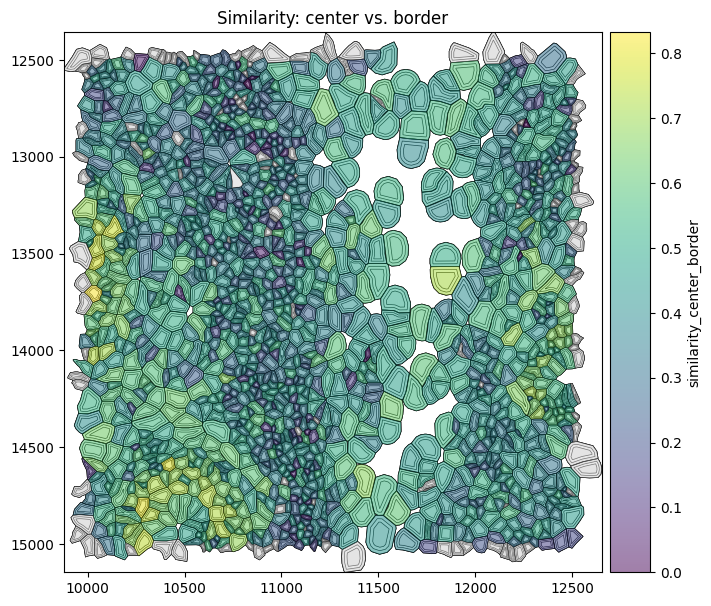

In [ ]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_borders",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_center_border",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    title="Similarity: center vs. border",
    colorbar=True,
    figsize=(6, 6),
)

## Similarity between the border and neighborhood
The function `similarity_border_neighborhood()` computes the cosine similarity between gene expression in the cell border and its surrounding neighborhood.

Specifically, it:
1. Defines the border region as the outer ring of each cell (with an inner buffer gap).
2. Identifies neighboring cells based on a distance threshold relative to cell size.
3. Aggregates transcripts from neighboring cells to obtain a neighborhood expression profile.
4. Computes expression profiles for the border and neighborhood.
5. Applies normalization and log transformation.
6. Computes cosine similarity between border and neighborhood expression.

In [63]:
border_nh_df = st.rs.similarity_border_neighborhood()

In [64]:
border_nh_df.head()

,cell_id,similarity_border_neighborhood
0,6327,0.590701
1,6328,0.507376
2,6330,0.502098
3,6331,0.649073
4,6332,0.591916


The histogram below shows the distribution of the similarity between the cell border and neighborhood.

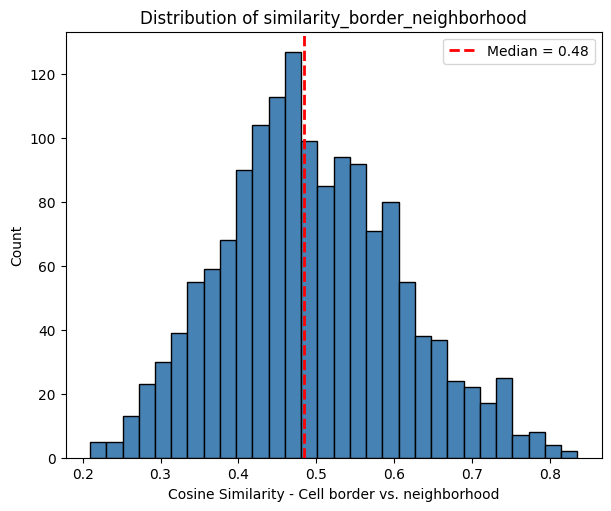

In [65]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_border_neighborhood",
    xlabel="Cosine Similarity - Cell border vs. neighborhood",
)

The spatial plots below shows the spatial distribution of computed similarity. 

INFO     Converted 1562 Polygon(s) with holes to MultiPolygon(s) for correct rendering.                            
WARNING  Found 72 NaN values in color data. These observations will be colored with the 'na_color'.                


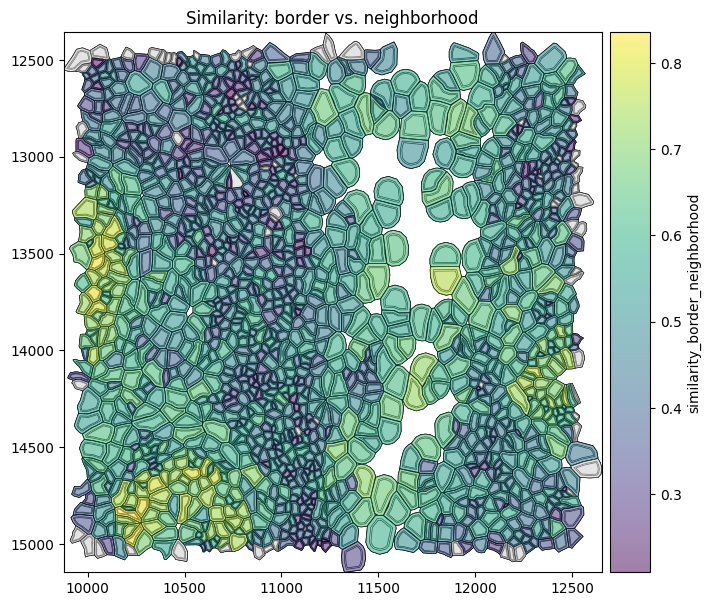

In [66]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_borders",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_border_neighborhood",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    title="Similarity: border vs. neighborhood",
    colorbar=True,
    figsize=(6, 6),
)

The border can resemble both the center and the neighborhood. A more specific indication of potential contamination can be obtained by comparing these similarities, for example via their ratio.

In [81]:
sdata.tables["table"].obs["neighborhood_center_ratio"] = (
    sdata.tables["table"].obs["similarity_border_neighborhood"] / sdata.tables["table"].obs["similarity_center_border"]
)
sdata.tables["table"].obs["neighborhood_center_ratio"] = (
    sdata.tables["table"].obs["neighborhood_center_ratio"].replace([np.inf, -np.inf], np.nan)
)
sdata.tables["table"].obs["neighborhood_center_ratio_clipped"] = (
    sdata.tables["table"]
    .obs["neighborhood_center_ratio"]
    .clip(upper=sdata.tables["table"].obs["neighborhood_center_ratio"].quantile(q=0.95))
)

WARNING  Found 128 NaN values in color data. These observations will be colored with the 'na_color'.               
WARNING  Found 72 NaN values in color data. These observations will be colored with the 'na_color'.                
WARNING  Found 130 NaN values in color data. These observations will be colored with the 'na_color'.               
WARNING  Found 130 NaN values in color data. These observations will be colored with the 'na_color'.               


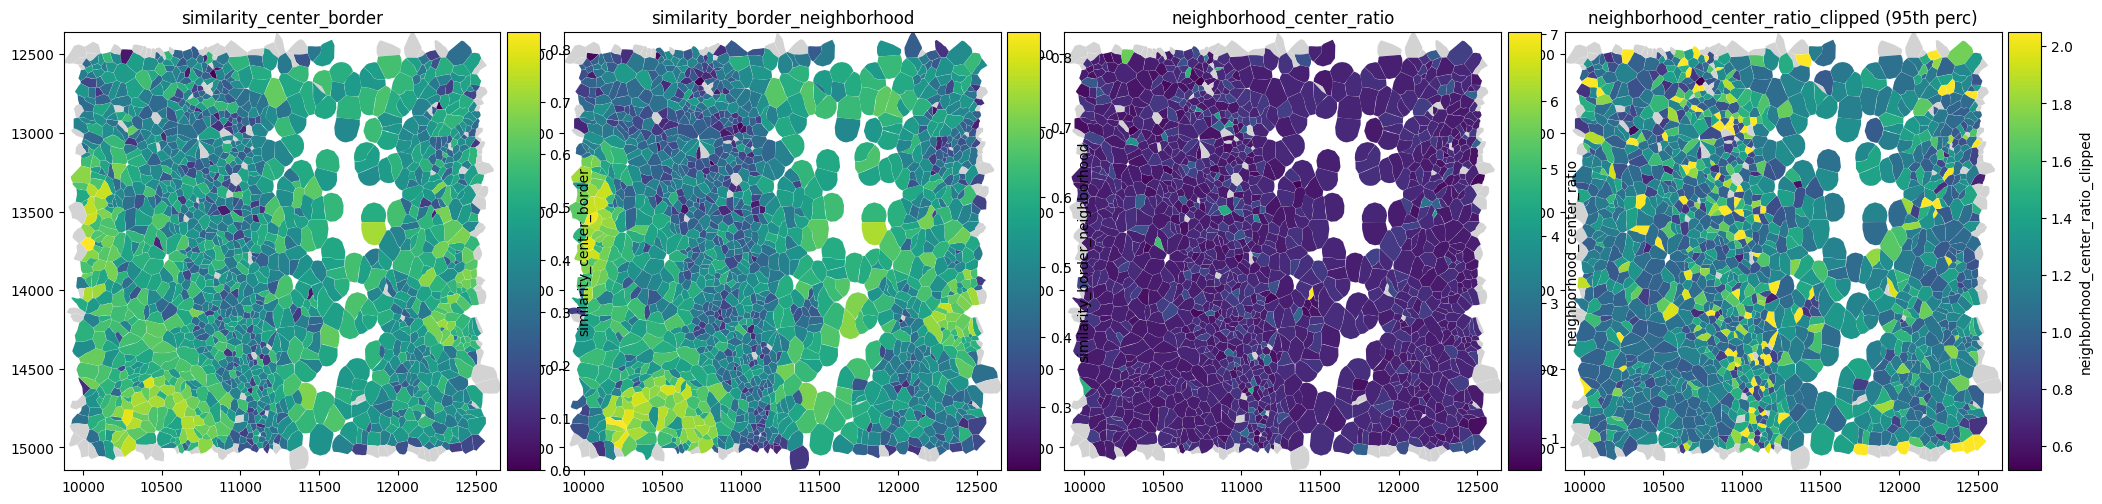

In [83]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(element="cell_boundaries", color="similarity_center_border").pl.show(
    ax=axes[0], title="similarity_center_border"
)
sdata.pl.render_shapes(element="cell_boundaries", color="similarity_border_neighborhood").pl.show(
    ax=axes[1], title="similarity_border_neighborhood"
)
sdata.pl.render_shapes(element="cell_boundaries", color="neighborhood_center_ratio").pl.show(
    ax=axes[2], title="neighborhood_center_ratio"
)
sdata.pl.render_shapes(element="cell_boundaries", color="neighborhood_center_ratio_clipped").pl.show(
    ax=axes[3], title="neighborhood_center_ratio_clipped (95th perc)"
)

## Border admixture score
The ratio between border–neighborhood and center–border similarity can be unstable, as it can become very large when the similarity between center and border is close to zero. A more robust metric is therefore the **border admixture score**, which explicitly models the border as a mixture of center and neighborhood expression.

Specifically, the function `border_admixture_score()`:

1. Computes gene expression profiles for center, border, and neighborhood regions.
2. Converts counts to gene proportions (with a small pseudocount).
3. Models the border profile as a mixture:

  $$
  p_{\text{border}} \approx (1 - \alpha)\, p_{\text{center}} + \alpha\, p_{\text{neighborhood}}
  $$

4. Estimates the mixture weight $\alpha$ using least squares.
5. Computes how much better this mixture explains the border compared to the center alone (`border_admixture_score`).
6. Estimates confidence intervals via bootstrap resampling.

The resulting score reflects how strongly the border resembles the neighborhood beyond what is expected from the center alone.

In [ ]:
st.rs.border_admixture_score(n_jobs=-1)

The histogram below shows the distribution of the border_admixture_score. 

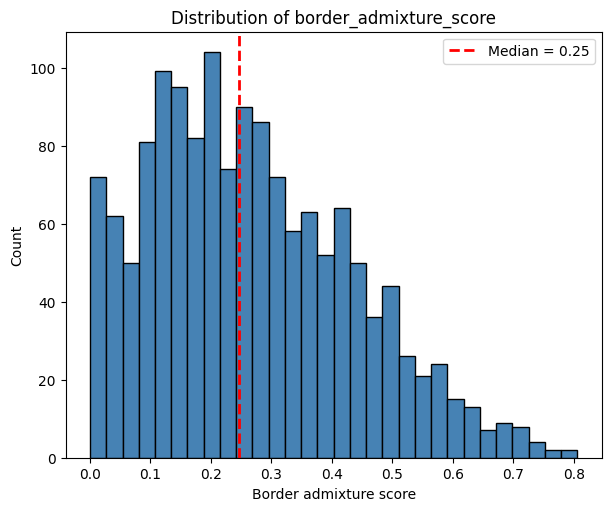

In [85]:
plot_histogram(
    df=sdata["table"].obs,
    column="border_admixture_score",
    xlabel="Border admixture score",
)

The confidence interval reflects the uncertainty in the border admixture score due to limited and noisy transcript counts, estimated via bootstrap resampling. It should be considered to distinguish robust signals from effects that could arise by chance, especially in sparse data.

A border_admixture_score > 0 indicates that including the neighborhood improves the fit to the border compared to using the center alone. A score of 1 means that the border expression is perfectly explained by a mixture of center and neighborhood.

To identify potentially contaminated cells, we use a threshold of 0.25 and require that the lower bound of the confidence interval exceeds this threshold, ensuring that only cells with a robust and consistent neighborhood contribution are selected.

In [89]:
obs = sdata.tables["table"].obs

obs["border_admixture_score_confident_binary"] = obs["border_admixture_score_ci_low"] > 0.25

obs["border_admixture_score_confident"] = obs["border_admixture_score"]

obs.loc[~obs["border_admixture_score_confident_binary"], "border_admixture_score_confident"] = np.nan

WARNING  Found 98 NaN values in color data. These observations will be colored with the 'na_color'.                
WARNING  Found 1296 NaN values in color data. These observations will be colored with the 'na_color'.              


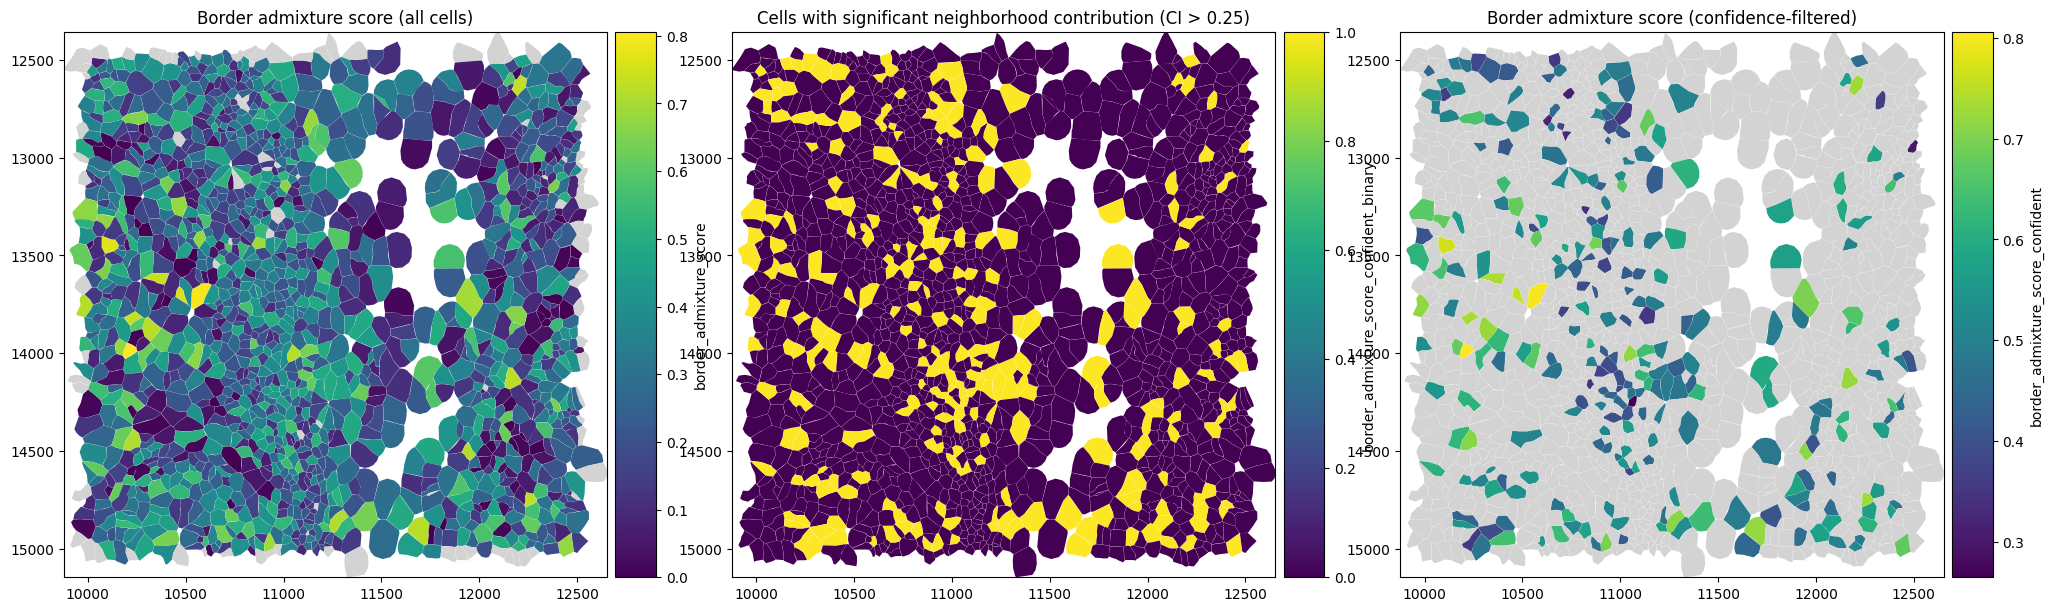

In [90]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(element="cell_boundaries", color="border_admixture_score").pl.show(
    ax=axes[0], title="Border admixture score (all cells)"
)

sdata.pl.render_shapes(element="cell_boundaries", color="border_admixture_score_confident_binary").pl.show(
    ax=axes[1], title="Cells with significant neighborhood contribution (CI > 0.25)"
)

sdata.pl.render_shapes(element="cell_boundaries", color="border_admixture_score_confident").pl.show(
    ax=axes[2], title="Border admixture score (confidence-filtered)"
)

## Session Info

In [91]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)

0.7.1.post1
0.2.14
